<a href="https://colab.research.google.com/github/sanusahana678-star/HomeLoan/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🏠 House Price Prediction Project  




In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


## 1️⃣ Load Dataset

In [16]:

df = pd.read_csv("HousePriceDataset.csv")
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2️⃣ Data Understanding

In [17]:

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False).head(10))


Shape: (1460, 81)

Data Types:
 Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Missing Values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


## 3️⃣ Missing Value Treatment

In [18]:

# Fill numerical with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()


np.int64(0)

## 4️⃣ Exploratory Data Analysis (EDA)

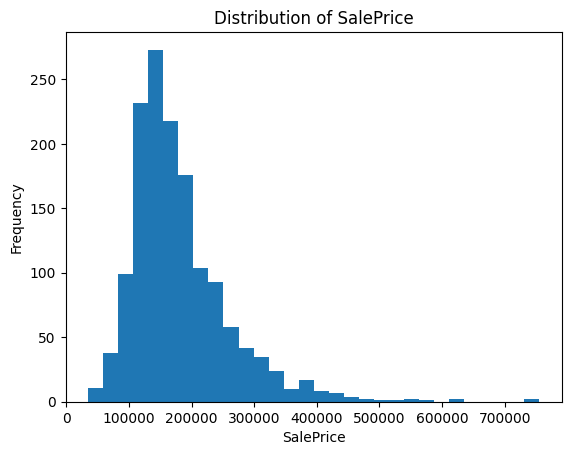

In [19]:

# Distribution of SalePrice
plt.figure()
plt.hist(df['SalePrice'], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()


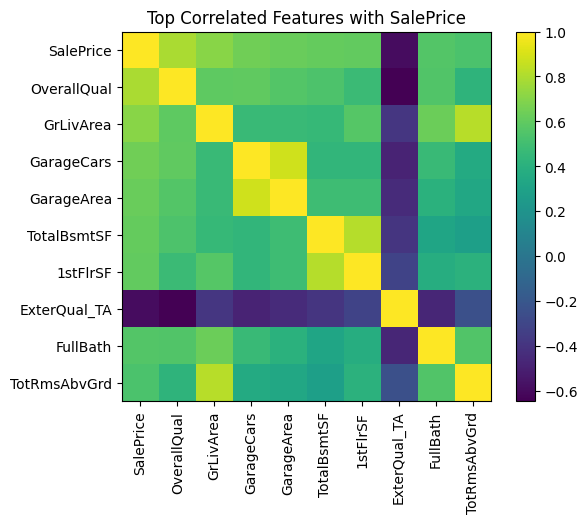

In [20]:
df = pd.get_dummies(df, drop_first=True)
# Correlation Heatmap (Top 10 correlated features)
corr = df.corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(10).index
plt.figure()
plt.imshow(df[top_corr].corr(), interpolation='nearest')
plt.title("Top Correlated Features with SalePrice")
plt.xticks(range(len(top_corr)), top_corr, rotation=90)
plt.yticks(range(len(top_corr)), top_corr)
plt.colorbar()
plt.show()

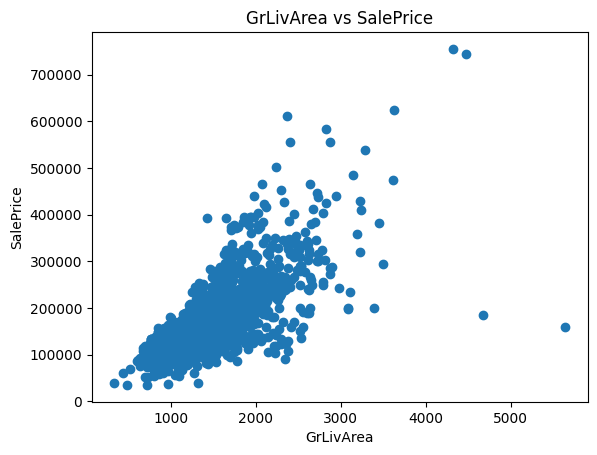

In [21]:

# GrLivArea vs SalePrice
plt.figure()
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()


## 5️⃣ Encoding Categorical Variables

In [22]:

df = pd.get_dummies(df, drop_first=True)
df.shape


(1460, 246)

## 6️⃣ Train-Test Split

In [23]:

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1168, 245)
Test shape: (292, 245)


## 7️⃣ Feature Scaling

In [24]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8️⃣ Model Training & Comparison

In [25]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    if name in ["Linear Regression", "Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "R2": r2}

pd.DataFrame(results).T.sort_values("RMSE")


,RMSE,R2
Gradient Boosting,27374.968582,0.902300
Random Forest,28798.150201,0.891878
Ridge,47889.754816,0.701000
Lasso,51259.813121,0.657437
Linear Regression,51405.094253,0.655493


## 9️⃣ Best Model Selection

In [26]:

best_model_name = min(results, key=lambda x: results[x]["RMSE"])
best_model_name


'Gradient Boosting'

## 🔟 Final Evaluation

Final RMSE: 27868.140720611547
Final R2 Score: 0.898748339217164


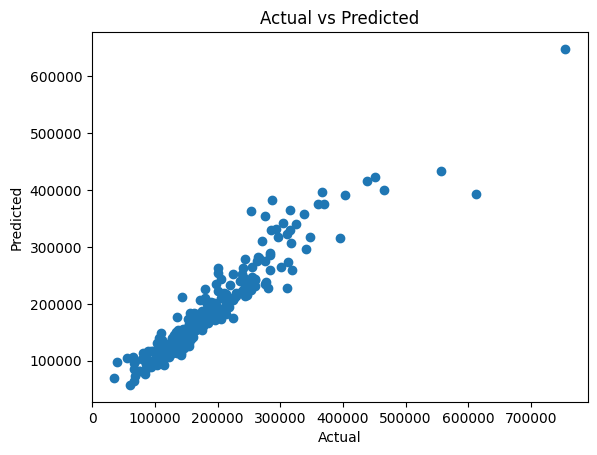

In [27]:

best_model = models[best_model_name]

if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    best_model.fit(X_train_scaled, y_train)
    final_preds = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    final_preds = best_model.predict(X_test)

print("Final RMSE:", np.sqrt(mean_squared_error(y_test, final_preds)))
print("Final R2 Score:", r2_score(y_test, final_preds))

plt.figure()
plt.scatter(y_test, final_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()



## 🏁 Conclusion

- Multiple regression models were trained and compared.
- Ensemble models (Random Forest / Gradient Boosting) generally perform better.
- The best model was selected based on lowest RMSE.
- Strong predictors include Overall Quality, GrLivArea, GarageCars, TotalBsmtSF.

The project successfully built an end-to-end ML pipeline.



## 🚀 Future Scope

- Hyperparameter tuning using GridSearchCV
- Advanced feature engineering
- Log transformation of SalePrice
- Use XGBoost / LightGBM
- Model stacking
- Deployment using Flask / Streamlit
